In [ ]:
import pandas as pd
import glob
import re
import os
import seaborn as sns
import numpy as np
import scanpy as sc
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
from scipy.stats import pointbiserialr, ttest_ind

def extract_feature(adata, feature):

    ad_subset = adata[:, adata.var['feature_types']==feature]

    obs_names = adata.obs.index.tolist()
    var_names = ad_subset.var_names
    array = ad_subset.X.toarray()

    df = pd.DataFrame(
        array,
        index=obs_names,
        columns=var_names
    )

    return df

tumours = [
 'AT3',
 'AT4',
 'AT5',
 'AT6',
 'AT7',
 'AT9',
 'AT10',
 'AT11',
 'AT12',
 'AT13',
 'AT14',
 'AT15',
]

ct_order_from_paper = [
 'Resident-TAMs',
 'Astrocyte-like TAMs',
 'Pro-inflammatory TAMs',
 'Interferon TAMs',
 'RTN1+ TAMs',
 'Proliferative TAMs',
 'Resident BAM TAMs',
 'Anti-inflammatory TAMs',
 'Monocytes',
 'Angiogenic TAMs',
 'Stress-response TAMs'
]

output_dir = '../../../data/EDFig10/'

import matplotlib as mpl
from matplotlib import colors
from matplotlib.lines import Line2D

mpl.rcParams['figure.dpi'] = 300
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

In [ ]:
# Load cell2loc output
sp_directory = '../../../data/GBM_LEAP_annotations/web_atlas/anndata/'
files = glob.glob(sp_directory+'*h5ad')

# load cell state spatial data
abundance_output = {}
niche_output = {}
histopath_output = {}

for tumour in tumours:
    tumour_files = [i for i in files if tumour+'-' in i]

    abundances = []
    niches = []
    histopaths = []
    
    for filepath in tumour_files:
        ad_tmp = sc.read_h5ad(filepath)
    
        abundances.append(extract_feature(ad_tmp, 'Cell state abundances'))
        niches.append(extract_feature(ad_tmp, 'Spatial niche abundances'))

        if 'Histopath annotation overlap' in set(ad_tmp.var['feature_types']):
            histopaths.append(extract_feature(ad_tmp, 'Histopath annotation overlap'))

    abundance_output[tumour] = pd.concat(abundances)
    niche_output[tumour] = pd.concat(niches)
    if len(histopaths)>0:
        histopath_output[tumour] = pd.concat(histopaths)

    del(ad_tmp)

/software/conda/users/gd11/scverse_new/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/software/conda/users/gd11/scverse_new/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/software/conda/users/gd11/scverse_new/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/software/conda/users/gd11/scverse_new/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/software/conda/users/gd11/scverse_new/lib/python3.10/site-packages/annd

In [ ]:
# feed top abundances into correlation:
median_TM_ct_corrs = []
for ct in ct_order_from_paper:
    for tumour in tumours:
        for TM in TM_list:

            # relabel TMs for paper
            if 'Hypoxic' in TM:
                TM = TM+' (niche)'
            if TM=='Neuron-like':
                TM = 'Dev-like (Neuron)'
            
                
            # get TM correlations & ct overlap
            if TM in niche_output[tumour].columns:
                if ct in abundance_output[tumour].columns:
                    
                    # correlation
                    r,p = pearsonr(abundance_output[tumour][ct],
                                     niche_output[tumour][TM])

                    # overlap
                    niche_spots = niche_output[tumour][TM]
                    niche_spots = niche_spots[(niche_spots>4) & 
                        (niche_spots>niche_spots.quantile(0.5))].index.tolist()

                    ct_df = abundance_output[tumour]
                    cts_in_tumour = [i for i in ct_order_from_paper if i in ct_df.columns]
                    prop = ct_df[ct].divide(ct_df[cts_in_tumour].sum(axis=1), axis=0).median()

                    # spot overlap
                    niche_spots = niche_output[tumour][TM]
                    niche_spots = niche_spots[(niche_spots>4) & 
                        (niche_spots>niche_spots.quantile(0.5))].index.tolist()

                    ct_spots = abundance_output[tumour][ct]
                    ct_spots = ct_spots[(ct_spots>4) & 
                        (ct_spots>ct_spots.quantile(0.5))].index.tolist()
                    spot_overlap = len([i for i in ct_spots if i in niche_spots])/len(niche_spots)
                    
                    
                    df = pd.DataFrame({'index':ct, 'TM':TM, 'r':r, 'p':p, 
                                       'prop':prop, 'spot_overlap':spot_overlap}, index=[0])
                    median_TM_ct_corrs.append(df)
median_TM_ct_corrs = pd.concat(median_TM_ct_corrs)
median_TM_ct_corrs = median_TM_ct_corrs.groupby(['index', 'TM']).median()

In [ ]:
# label hotfix
mean_TM_abundances = mean_TM_abundances.rename(
    index={
        "Hypoxic 1": "Hypoxic 1 (niche)",
        "Hypoxic 2": "Hypoxic 2 (niche)",
        "Neuron-like": "Dev-like (Neuron)",
    },
    level="TM"
)

# prep df to ensure symmetry:
mean_TM_abundances = mean_TM_abundances[mean_TM_abundances.index.get_level_values("index").isin(ct_order_from_paper)]

tms_A = set(mean_TM_abundances.index.get_level_values('TM'))
tms_B = set(median_TM_ct_corrs.index.get_level_values('TM'))
print(len(tms_A)==len(tms_B))
print([i for i in tms_A if i not in tms_B])

t_A = set(mean_TM_abundances.index.get_level_values('index'))
t_B = set(median_TM_ct_corrs.index.get_level_values('index'))
print(len(t_A)==len(t_B))
print([i for i in t_A if i not in t_B])

True
[]
True
[]


In [ ]:
plot_df = pd.concat([mean_TM_abundances, median_TM_ct_corrs], axis=1).reset_index()

In [ ]:
TM_order_from_paper = [
    'Grey matter', 'White matter', 'Immune (resident)', 
    'Immune (TAMs)', 'Vasculature', 'Dev-like (OPC)', 
    'Dev-like (AC)', 'Proliferative', 'Gliosis transition', 
    'Gliosis', 'Hypoxic 1 (niche)']

plot_df["index"] = pd.Categorical(
    plot_df["index"],
    categories=ct_order_from_paper,
    ordered=True
)

plot_df["TM"] = pd.Categorical(
    plot_df["TM"],
    categories=TM_order_from_paper,
    ordered=True
)

In [ ]:
set(mean_TM_abundances.index.get_level_values('index'))

{'Angiogenic TAMs',
 'Anti-inflammatory TAMs',
 'Astrocyte-like TAMs',
 'Interferon TAMs',
 'Monocytes',
 'Pro-inflammatory TAMs',
 'Proliferative TAMs',
 'RTN1+ TAMs',
 'Resident BAM TAMs',
 'Resident-TAMs',
 'Stress-response TAMs'}

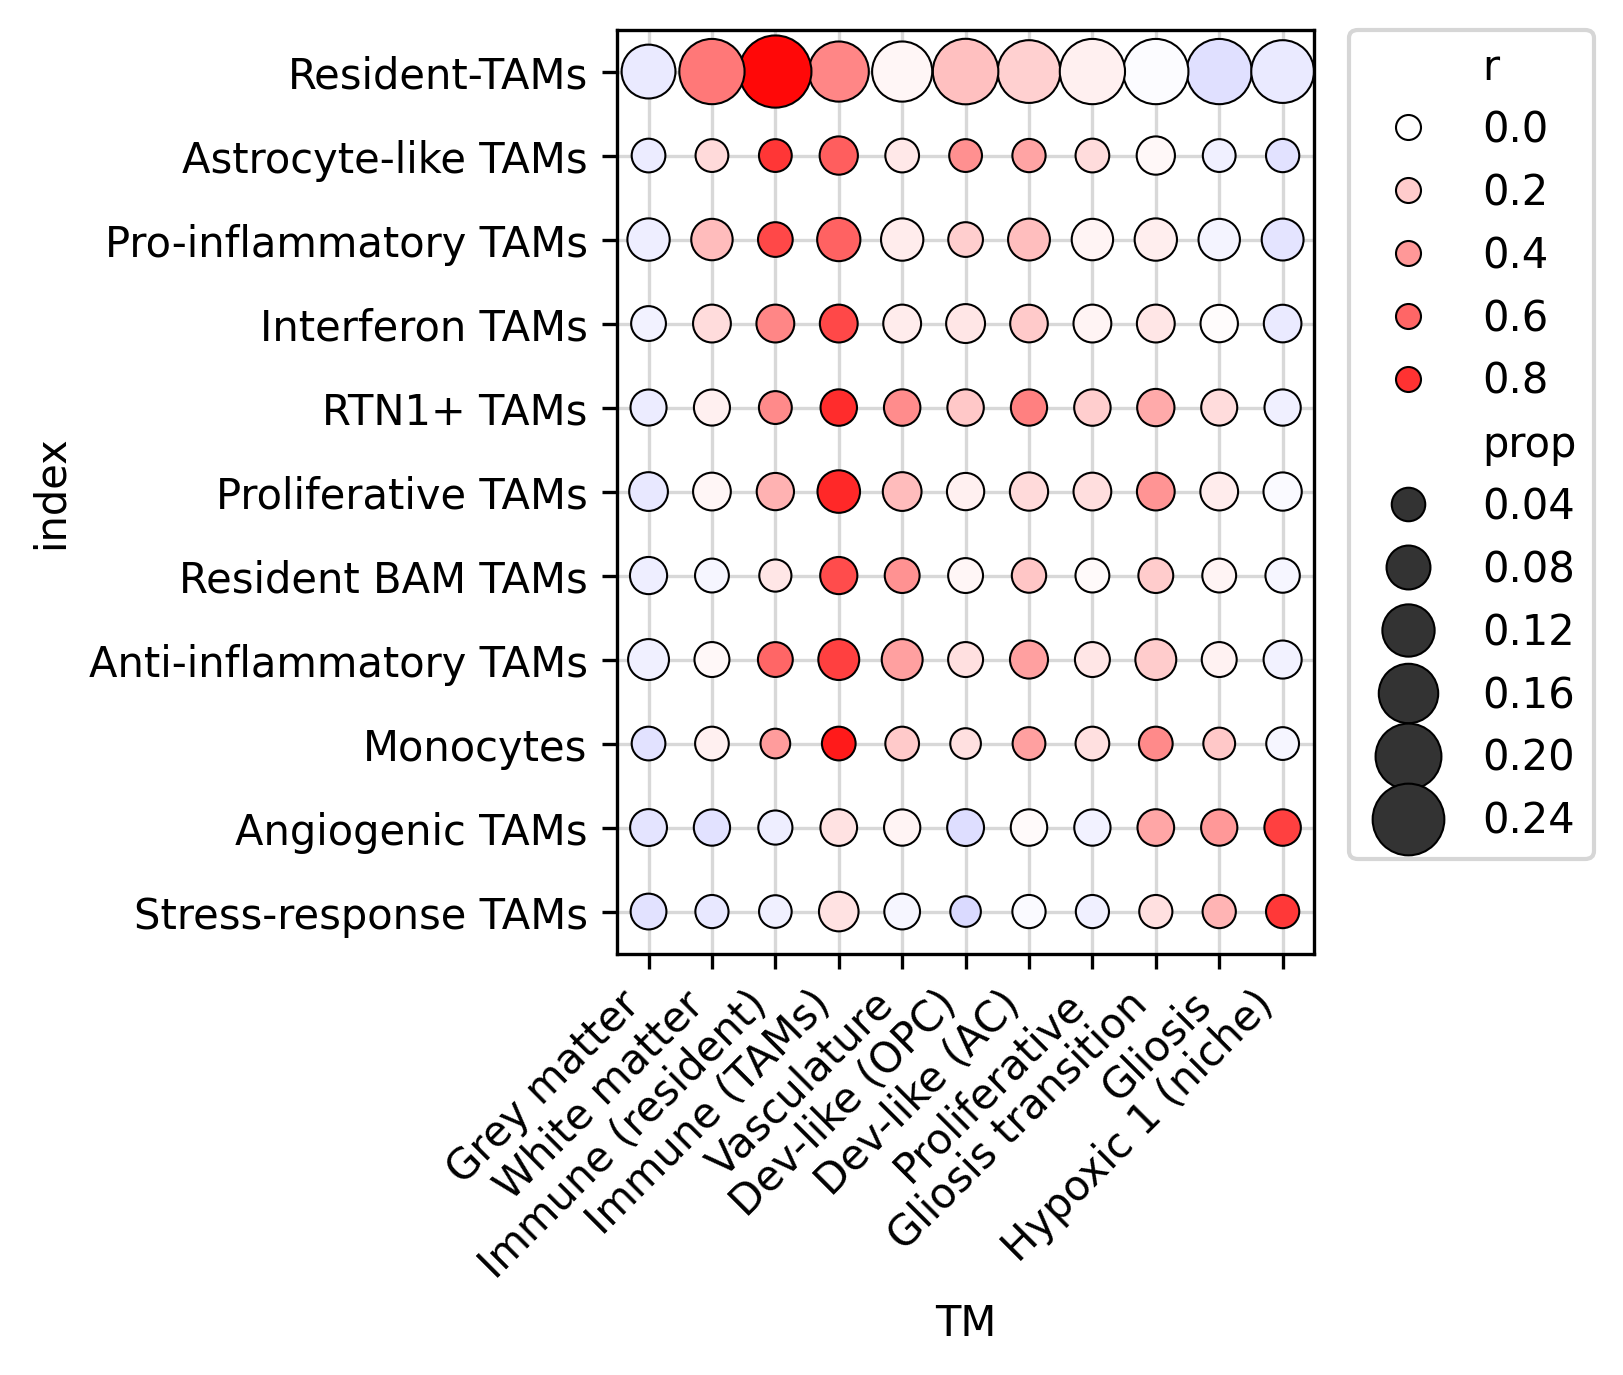

In [ ]:
plt.figure(figsize=(3, 4))

ax = sns.scatterplot(data=plot_df, y = 'index', x = 'TM', 
                size = 'prop', hue = 'r', 
                palette="bwr", hue_norm=(-1, 1),
                linewidth = 0.5, edgecolor = 'black',
                sizes=(50, 300)
)
# rotate x-axis labels
plt.xticks(rotation=45, ha="right")

# move legend to the right
plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    borderaxespad=0
)
ax.grid(True, color="grey", alpha=0.3, zorder=-1)
ax.set_axisbelow(True)

plt.savefig('../data/myeloid/EDFig10a5.pdf')

In [ ]:
plot_df.dropna().to_csv(os.path.join(output_dir, 'EDFig10a5.csv'))